# Ridge Regression GK Volatility Prediction

**Task**: Predict next-hour Garman-Klass Volatility (`target_reg`)  
**Models**: Ridge Regression from scratch (Normal Equation + Gradient Descent) and sklearn  
**Ridge is**: Linear regression with L2 regularisation adds $\lambda \sum w_j^2$ penalty to prevent overfitting  
**Closed-form solution**: $\hat{w} = (X^TX + \lambda I)^{-1}X^Ty$  


---
## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
)
from sklearn.preprocessing import StandardScaler

# File paths
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_regression.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_regression.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'regression_results.csv')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

# Shared utility: compute regression metrics 
def compute_metrics(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10)))) * 100
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  MSE     : {mse:.8f}")
    print(f"  RMSE    : {rmse:.8f}")
    print(f"  MAE     : {mae:.8f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE(%) : {mape:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'mse': round(mse,8), 'rmse': round(rmse,8),
            'mae': round(mae,8), 'r2': round(r2,4), 'mape': round(mape,4)}

# results to CSV 
def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved → {RESULTS_CSV}")

print('Libraries loaded')
print(f'BASE_DIR    : {BASE_DIR}')
print(f'RESULTS_DIR : {RESULTS_DIR}')
print(f'PLOTS_DIR   : {PLOTS_DIR}')


Libraries loaded
BASE_DIR    : d:\ML\crypto project\cryptoflow
RESULTS_DIR : d:\ML\crypto project\cryptoflow\results
PLOTS_DIR   : d:\ML\crypto project\cryptoflow\plots


In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['open time'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['open time'])

with open(FEATURES_FILE) as f:
    feature_cols = json.load(f)

if os.path.exists(SCALER_FILE):
    with open(SCALER_FILE, 'rb') as f:
        scaler = pickle.load(f)
    X_train = scaler.transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)
else:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)

y_train = train['target_reg'].values
y_test  = test['target_reg'].values

val_cut = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')


Train: 60,260 rows | Test: 10,635 rows
X_train: (60260, 10) | X_test: (10635, 10)
Features (10): ['hl_range_pct', 'gk_avg_6h', 'gk_lag_6h', 'hour_cos', 'gk_avg_3h', 'gk_lag_1h', 'trade_intensity', 'log_return_3h', 'log_return_6h', 'atr_lag_3h']


In [3]:
# ── Scale target variable ─────────────────────────────────────────────────────
# GK volatility values are tiny (e.g. 1e-5). Scaling the target is critical
# for Gradient Descent to converge properly. R² is unaffected by scaling.
from sklearn.preprocessing import StandardScaler as TargetScaler

y_scaler = TargetScaler()
y_train  = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test   = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
y_tr     = y_train[:val_cut]
y_val    = y_train[val_cut:]

with open(os.path.join(MODELS_DIR, 'target_scaler.pkl'), 'wb') as f:
    pickle.dump(y_scaler, f)

print(f'Target scaled — y_train mean: {y_train.mean():.4f}, std: {y_train.std():.4f}')
print(f'Target scaled — y_test  mean: {y_test.mean():.4f},  std: {y_test.std():.4f}')


Target scaled — y_train mean: 0.0000, std: 1.0000
Target scaled — y_test  mean: -0.3871,  std: 0.5408


---
## 2. Data Analysis

=== Target Variable Statistics ===
              Train          Test
count  60260.000000  10635.000000
mean       0.000000     -0.387147
std        1.000008      0.540801
min       -1.062253     -1.022464
25%       -0.566749     -0.715108
50%       -0.264825     -0.527962
75%        0.240043     -0.229234
max       36.017812     13.773550


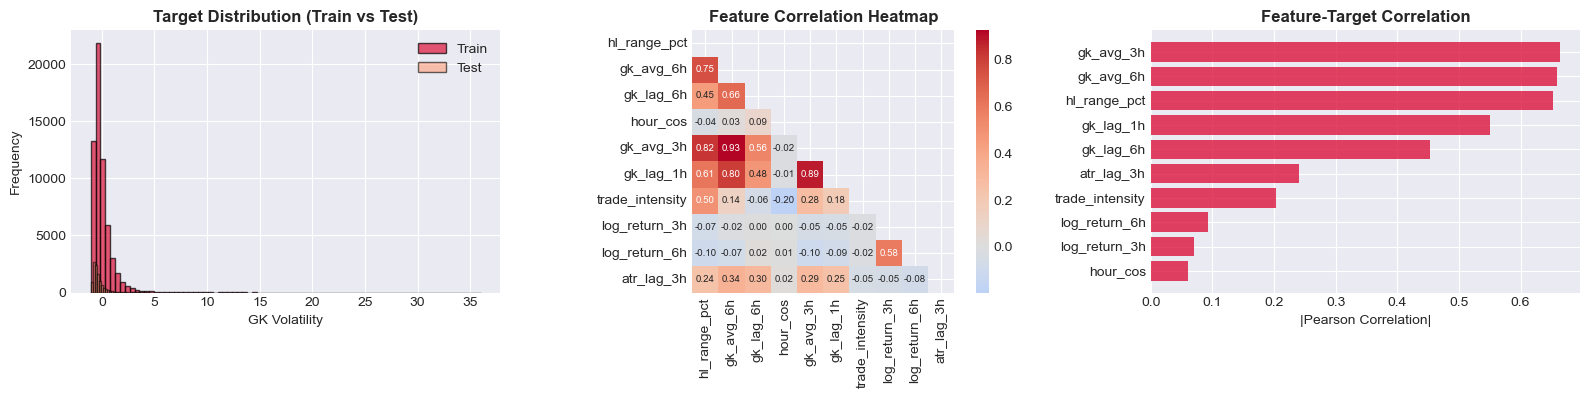

In [4]:
print('=== Target Variable Statistics ===')
print(pd.DataFrame({'Train': pd.Series(y_train).describe(),
                    'Test' : pd.Series(y_test).describe()}).round(8))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=80, alpha=0.7, color='crimson', edgecolor='black', label='Train')
axes[0].hist(y_test,  bins=80, alpha=0.6, color='lightsalmon', edgecolor='black', label='Test')
axes[0].set_xlabel('GK Volatility'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution (Train vs Test)', fontweight='bold')
axes[0].legend()

df_feat = pd.DataFrame(X_train, columns=feature_cols)
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

feat_target_corr = df_feat.corrwith(pd.Series(y_train)).abs().sort_values(ascending=True)
axes[2].barh(feat_target_corr.index, feat_target_corr.values, color='crimson', alpha=0.8)
axes[2].set_xlabel('|Pearson Correlation|')
axes[2].set_title('Feature-Target Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ridge_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Ridge Regression from Scratch

**Key difference from Linear Regression**: adds $\lambda$ penalty to the Normal Equation:

$$\hat{w} = (X^TX + \lambda I)^{-1}X^Ty$$

This shrinks weights toward zero, reducing overfitting when features are correlated.  
**Gradient Descent** update with L2 penalty:

$$w_j \leftarrow w_j - \alpha \left(\frac{2}{n}X^T(Xw-y) + 2\lambda w_j\right)$$


In [5]:
class RidgeRegressionScratch:
    """
    Ridge Regression from scratch.
    Supports:
    - Normal Equation: w = (X'X + lambda*I)^-1 X'y  (closed-form, exact)
    - Mini-batch Gradient Descent with L2 weight decay
    """
    def __init__(self, alpha=1.0, method='normal', learning_rate=0.005,
                 n_epochs=100, batch_size=256, verbose=True):
        self.alpha        = alpha      # L2 regularisation strength (lambda)
        self.method       = method
        self.lr           = learning_rate
        self.n_epochs     = n_epochs
        self.batch_size   = batch_size
        self.verbose      = verbose
        self.weights      = None
        self.bias         = None
        self.train_losses = []
        self.val_losses   = []

    def fit(self, X, y, X_val=None, y_val=None):
        n, p = X.shape

        if self.method == 'normal':
            # Augmented system: [1 | X] for bias + weights
            Xb    = np.hstack([np.ones((n, 1)), X])
            # Ridge penalty: do NOT penalise bias (first diagonal element = 0)
            I_reg = np.eye(p + 1)
            I_reg[0, 0] = 0
            theta = np.linalg.solve(Xb.T @ Xb + self.alpha * I_reg, Xb.T @ y)
            self.bias    = float(theta[0])
            self.weights = theta[1:]
            self.train_losses = [float(np.mean((self.predict(X) - y) ** 2))]
            print(f"  Normal Equation solved (alpha={self.alpha}). "
                  f"Train MSE: {self.train_losses[0]:.8f}")

        elif self.method == 'gradient_descent':
            self.weights      = np.zeros(p)
            self.bias         = 0.0
            self.train_losses = []
            self.val_losses   = []

            for epoch in range(self.n_epochs):
                idx = np.random.permutation(n)
                Xs, ys = X[idx], y[idx]
                for start in range(0, n, self.batch_size):
                    Xb = Xs[start:start+self.batch_size]
                    yb = ys[start:start+self.batch_size]
                    nb = len(yb)
                    err = Xb @ self.weights + self.bias - yb
                    # L2 gradient: normal gradient + 2*alpha*w (weight decay)
                    self.weights -= self.lr * ((2/nb) * (Xb.T @ err) + 2 * self.alpha * self.weights)
                    self.bias    -= self.lr * (2/nb) * err.sum()

                train_mse = float(np.mean((self.predict(X) - y) ** 2))
                self.train_losses.append(train_mse)
                if X_val is not None:
                    self.val_losses.append(
                        float(np.mean((self.predict(X_val) - y_val) ** 2)))

                if self.verbose and (epoch + 1) % 10 == 0:
                    msg = f'  Epoch {epoch+1:3d}/{self.n_epochs} — Train MSE: {train_mse:.8f}'
                    if X_val is not None:
                        msg += f' | Val MSE: {self.val_losses[-1]:.8f}'
                    print(msg)
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

    def get_coefficients(self, feature_names=None):
        names = feature_names or [f'x{i}' for i in range(len(self.weights))]
        return pd.Series(self.weights, index=names).sort_values(key=abs, ascending=False)

print('RidgeRegressionScratch defined')


RidgeRegressionScratch defined


---
## 4. Alpha (λ) Grid Search

=== Alpha Grid Search ===
  Normal Equation solved (alpha=1e-06). Train MSE: 0.54327844
  alpha=0.000  val_MSE=0.24031699
  Normal Equation solved (alpha=5e-06). Train MSE: 0.54327844
  alpha=0.000  val_MSE=0.24031699
  Normal Equation solved (alpha=1e-05). Train MSE: 0.54327844
  alpha=0.000  val_MSE=0.24031699
  Normal Equation solved (alpha=5e-05). Train MSE: 0.54327844
  alpha=0.000  val_MSE=0.24031699
  Normal Equation solved (alpha=0.0001). Train MSE: 0.54327844
  alpha=0.000  val_MSE=0.24031699
  Normal Equation solved (alpha=0.0005). Train MSE: 0.54327844
  alpha=0.001  val_MSE=0.24031699
  Normal Equation solved (alpha=0.001). Train MSE: 0.54327844
  alpha=0.001  val_MSE=0.24031699
  Normal Equation solved (alpha=0.01). Train MSE: 0.54327844
  alpha=0.010  val_MSE=0.24031698
  Normal Equation solved (alpha=0.05). Train MSE: 0.54327844
  alpha=0.050  val_MSE=0.24031698
  Normal Equation solved (alpha=0.1). Train MSE: 0.54327844
  alpha=0.100  val_MSE=0.24031697

Best alpha: 0.1

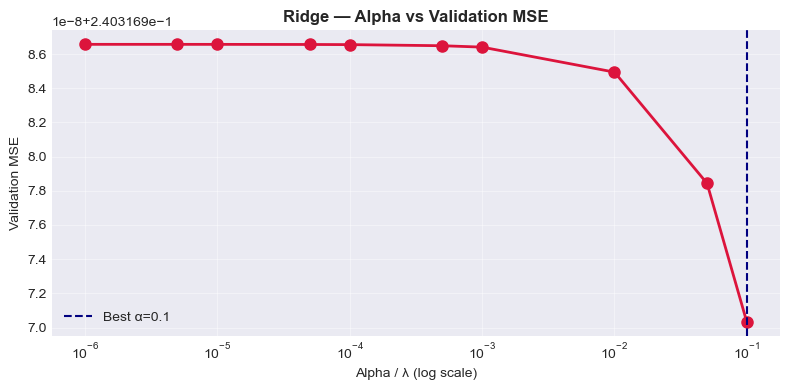

In [6]:
print('=== Alpha Grid Search ===')
alphas = [
    1e-6, 5e-6, 1e-5, 5e-5,
    1e-4, 5e-4, 1e-3,
    1e-2, 5e-2, 1e-1
]
alpha_results = []

for a in alphas:
    m = RidgeRegressionScratch(alpha=a, method='normal', verbose=False)
    m.fit(X_tr, y_tr)
    val_mse = float(mean_squared_error(y_val, m.predict(X_val)))
    alpha_results.append({'alpha': a, 'val_mse': val_mse})
    print(f'  alpha={a:.3f}  val_MSE={val_mse:.8f}')

df_alpha   = pd.DataFrame(alpha_results)
best_alpha = float(df_alpha.loc[df_alpha['val_mse'].idxmin(), 'alpha'])
print(f'\nBest alpha: {best_alpha}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx([r['alpha'] for r in alpha_results],
            [r['val_mse'] for r in alpha_results],
            'o-', color='crimson', lw=2, ms=8)
ax.axvline(best_alpha, color='navy', ls='--', lw=1.5, label=f'Best α={best_alpha}')
ax.set_xlabel('Alpha / λ (log scale)'); ax.set_ylabel('Validation MSE')
ax.set_title('Ridge — Alpha vs Validation MSE', fontweight='bold')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ridge_alpha_selection.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Train Ridge Regression from Scratch

In [7]:
# Normal Equation
ridge_normal = RidgeRegressionScratch(alpha=best_alpha, method='normal')
ridge_normal.fit(X_train, y_train)
y_pred_train_normal = ridge_normal.predict(X_train)
y_pred_test_normal  = ridge_normal.predict(X_test)
print('Normal Equation done')


  Normal Equation solved (alpha=0.1). Train MSE: 0.49750193
Normal Equation done


In [8]:
# Gradient Descent
ridge_gd = RidgeRegressionScratch(alpha=best_alpha, method='gradient_descent',
                                   learning_rate=0.01, n_epochs=300,
                                   batch_size=128, verbose=True)
ridge_gd.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)
y_pred_train_gd = ridge_gd.predict(X_train)
y_pred_test_gd  = ridge_gd.predict(X_test)
print('Gradient Descent done')


  Epoch  10/300 — Train MSE: 0.54870527 | Val MSE: 0.24328752
  Epoch  20/300 — Train MSE: 0.54994296 | Val MSE: 0.24866508
  Epoch  30/300 — Train MSE: 0.55593937 | Val MSE: 0.24233623
  Epoch  40/300 — Train MSE: 0.55037482 | Val MSE: 0.24492780
  Epoch  50/300 — Train MSE: 0.55199632 | Val MSE: 0.24891034
  Epoch  60/300 — Train MSE: 0.55191245 | Val MSE: 0.24128970
  Epoch  70/300 — Train MSE: 0.55117246 | Val MSE: 0.24431689
  Epoch  80/300 — Train MSE: 0.55084086 | Val MSE: 0.23999045
  Epoch  90/300 — Train MSE: 0.54803037 | Val MSE: 0.24644968
  Epoch 100/300 — Train MSE: 0.55433084 | Val MSE: 0.24521804
  Epoch 110/300 — Train MSE: 0.54811497 | Val MSE: 0.24314123
  Epoch 120/300 — Train MSE: 0.54997333 | Val MSE: 0.24502288
  Epoch 130/300 — Train MSE: 0.54663564 | Val MSE: 0.23922286
  Epoch 140/300 — Train MSE: 0.55712904 | Val MSE: 0.23993636
  Epoch 150/300 — Train MSE: 0.54974793 | Val MSE: 0.24389860
  Epoch 160/300 — Train MSE: 0.55566549 | Val MSE: 0.24638915
  Epoch 

---
## 6. Ridge Regression sklearn

In [9]:
ridge_sk = Ridge(alpha=best_alpha)
ridge_sk.fit(X_train, y_train)
y_pred_train_sk = ridge_sk.predict(X_train)
y_pred_test_sk  = ridge_sk.predict(X_test)
print('Ridge Regression (sklearn) done')

print('\nScratch vs sklearn R² comparison:')
print(f'  Normal Eq : {r2_score(y_test, y_pred_test_normal):.4f}')
print(f'  GD        : {r2_score(y_test, y_pred_test_gd):.4f}')
print(f'  sklearn   : {r2_score(y_test, y_pred_test_sk):.4f}')


Ridge Regression (sklearn) done

Scratch vs sklearn R² comparison:
  Normal Eq : 0.3683
  GD        : 0.3288
  sklearn   : 0.3683


---
## 7. Loss & Regression Metrics (MSE / RMSE / MAE / R² / MAPE)

In [10]:
models_pred = {
    f'Ridge Normal (scratch, α={best_alpha})': (y_pred_train_normal, y_pred_test_normal),
    f'Ridge GD (scratch, α={best_alpha})'    : (y_pred_train_gd,     y_pred_test_gd),
    f'Ridge sklearn (α={best_alpha})'        : (y_pred_train_sk,     y_pred_test_sk),
}

all_metrics = {}
for name, (y_tr_p, y_te_p) in models_pred.items():
    all_metrics[name] = compute_metrics(name, y_test, y_te_p)

for name, m in all_metrics.items():
    save_results(m)



  Ridge Normal (scratch, α=0.1)
  MSE     : 0.18472801
  RMSE    : 0.42979997
  MAE     : 0.28054489
  R²      : 0.3683
  MAPE(%) : 242.5020

  Ridge GD (scratch, α=0.1)
  MSE     : 0.19627526
  RMSE    : 0.44302964
  MAE     : 0.30763195
  R²      : 0.3288
  MAPE(%) : 221.2705

  Ridge sklearn (α=0.1)
  MSE     : 0.18472801
  RMSE    : 0.42979997
  MAE     : 0.28054489
  R²      : 0.3683
  MAPE(%) : 242.5020
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv


---
## 8. R² Score

=== R² Score Summary ===
Ridge Normal (scratch, α=0.1)        Train R²: 0.502498  |  Test R²: 0.368318
Ridge GD (scratch, α=0.1)            Train R²: 0.480988  |  Test R²: 0.328832
Ridge sklearn (α=0.1)                Train R²: 0.502498  |  Test R²: 0.368318


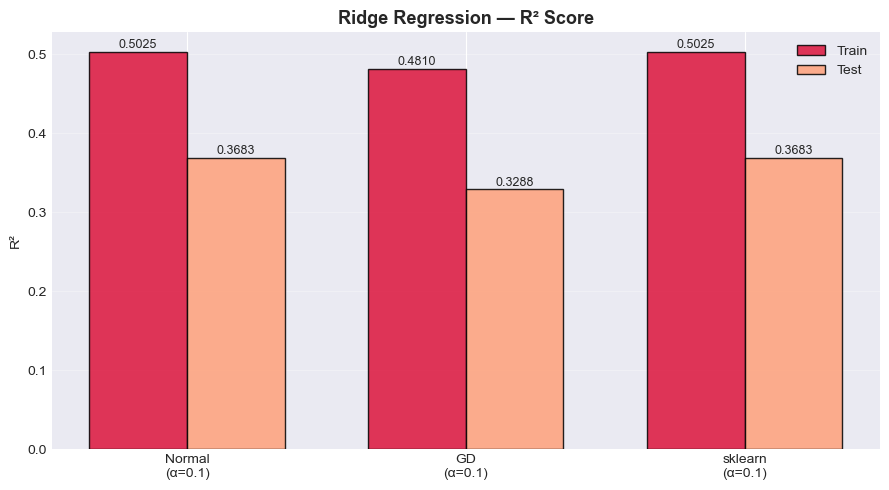

In [11]:
print('=== R² Score Summary ===')
for name, (y_tr_p, y_te_p) in models_pred.items():
    print(f'{name:35s}  Train R²: {r2_score(y_train, y_tr_p):.6f}  |  Test R²: {r2_score(y_test, y_te_p):.6f}')

short         = [f'Normal\n(α={best_alpha})', f'GD\n(α={best_alpha})', f'sklearn\n(α={best_alpha})']
r2_train_vals = [r2_score(y_train, v[0]) for v in models_pred.values()]
r2_test_vals  = [r2_score(y_test,  v[1]) for v in models_pred.values()]

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w/2, r2_train_vals, w, label='Train', color='crimson',     alpha=0.85, edgecolor='black')
b2 = ax.bar(x+w/2, r2_test_vals,  w, label='Test',  color='lightsalmon', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('R²'); ax.set_title('Ridge Regression — R² Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in [(b,vv) for bars,vs in [(b1,r2_train_vals),(b2,r2_test_vals)] for b,vv in zip(bars,vs)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ridge_r2.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Performance Curves (Loss)

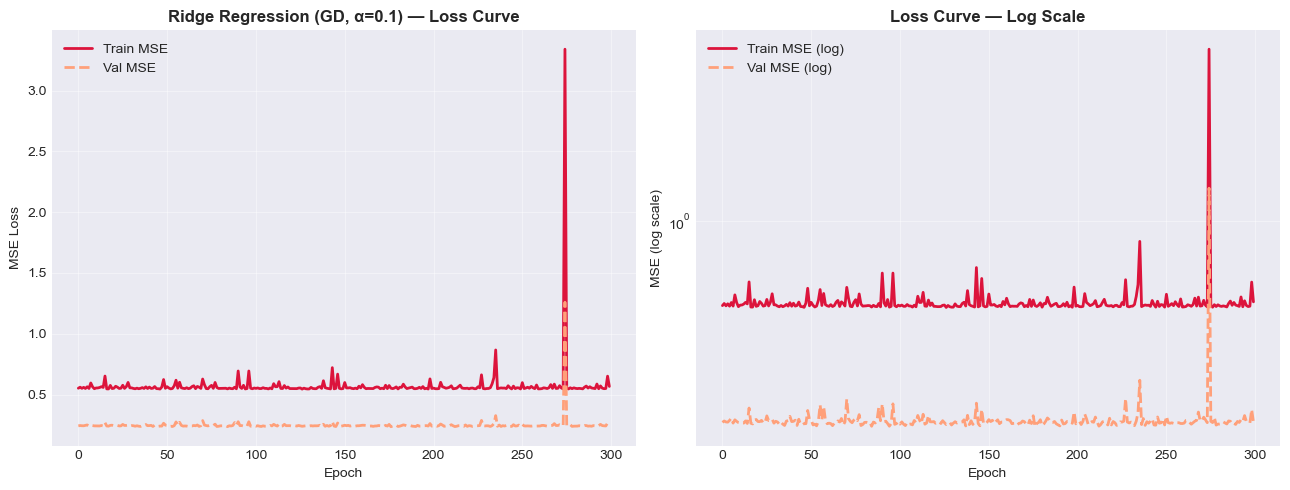

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ridge_gd.train_losses, color='crimson', lw=2, label='Train MSE')
if ridge_gd.val_losses:
    axes[0].plot(ridge_gd.val_losses, color='lightsalmon', lw=2, ls='--', label='Val MSE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title(f'Ridge Regression (GD, α={best_alpha}) — Loss Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].semilogy(ridge_gd.train_losses, color='crimson', lw=2, label='Train MSE (log)')
if ridge_gd.val_losses:
    axes[1].semilogy(ridge_gd.val_losses, color='lightsalmon', lw=2, ls='--', label='Val MSE (log)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (log scale)')
axes[1].set_title('Loss Curve — Log Scale', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ridge_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 14. Actual vs Predicted & Residual Analysis

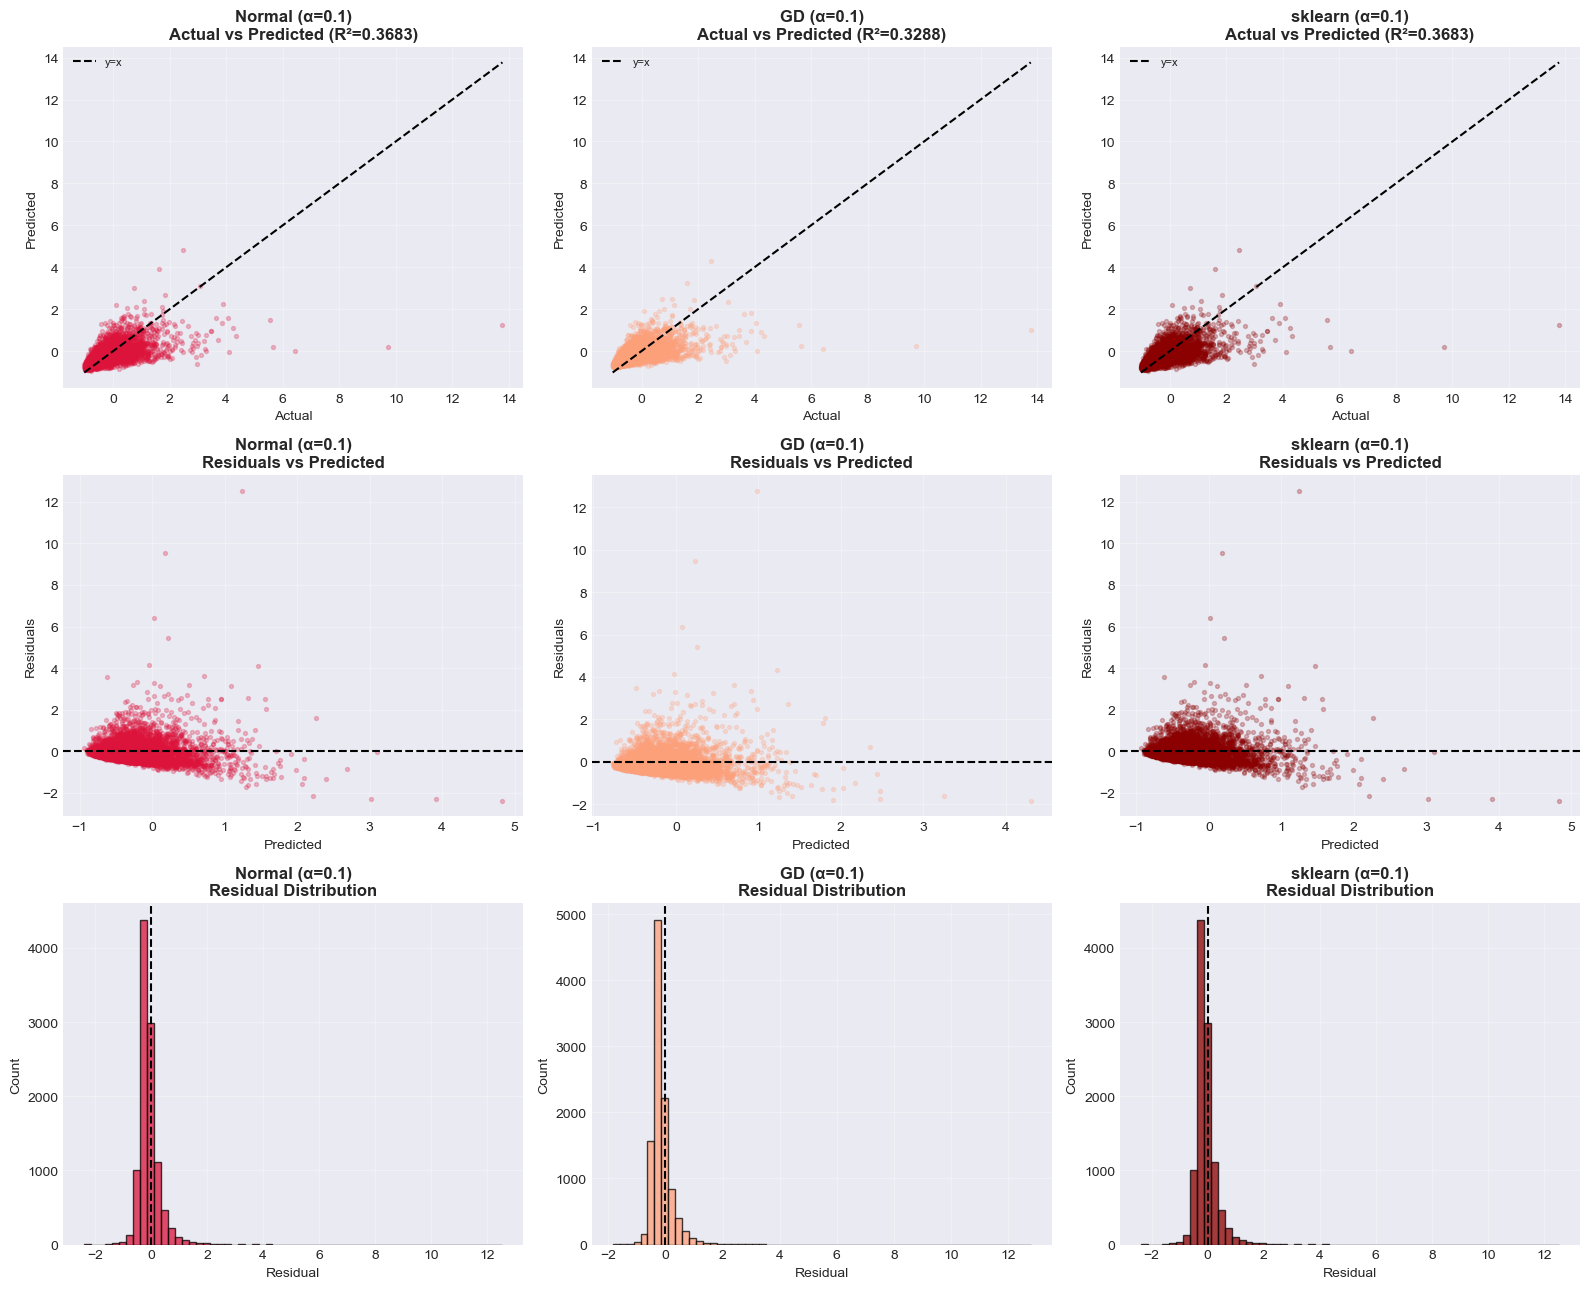

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
pred_list = [
    (f'Normal (α={best_alpha})', y_pred_test_normal, 'crimson'),
    (f'GD (α={best_alpha})',     y_pred_test_gd,     'lightsalmon'),
    (f'sklearn (α={best_alpha})',y_pred_test_sk,     'darkred'),
]

for col, (title, y_pred, color) in enumerate(pred_list):
    axes[0,col].scatter(y_test, y_pred, alpha=0.25, s=8, color=color)
    mn, mx = min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())
    axes[0,col].plot([mn,mx],[mn,mx],'k--',lw=1.5,label='y=x')
    r2 = r2_score(y_test, y_pred)
    axes[0,col].set_title(f'{title}\nActual vs Predicted (R²={r2:.4f})', fontweight='bold')
    axes[0,col].set_xlabel('Actual'); axes[0,col].set_ylabel('Predicted')
    axes[0,col].legend(fontsize=8); axes[0,col].grid(alpha=0.3)

    res = y_test - y_pred
    axes[1,col].scatter(y_pred, res, alpha=0.25, s=8, color=color)
    axes[1,col].axhline(0, color='black', lw=1.5, ls='--')
    axes[1,col].set_title(f'{title}\nResiduals vs Predicted', fontweight='bold')
    axes[1,col].set_xlabel('Predicted'); axes[1,col].set_ylabel('Residuals')
    axes[1,col].grid(alpha=0.3)

    axes[2,col].hist(res, bins=60, color=color, alpha=0.75, edgecolor='black')
    axes[2,col].axvline(0, color='black', lw=1.5, ls='--')
    axes[2,col].set_title(f'{title}\nResidual Distribution', fontweight='bold')
    axes[2,col].set_xlabel('Residual'); axes[2,col].set_ylabel('Count')
    axes[2,col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ridge_residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 15. Time-Series Prediction Plot

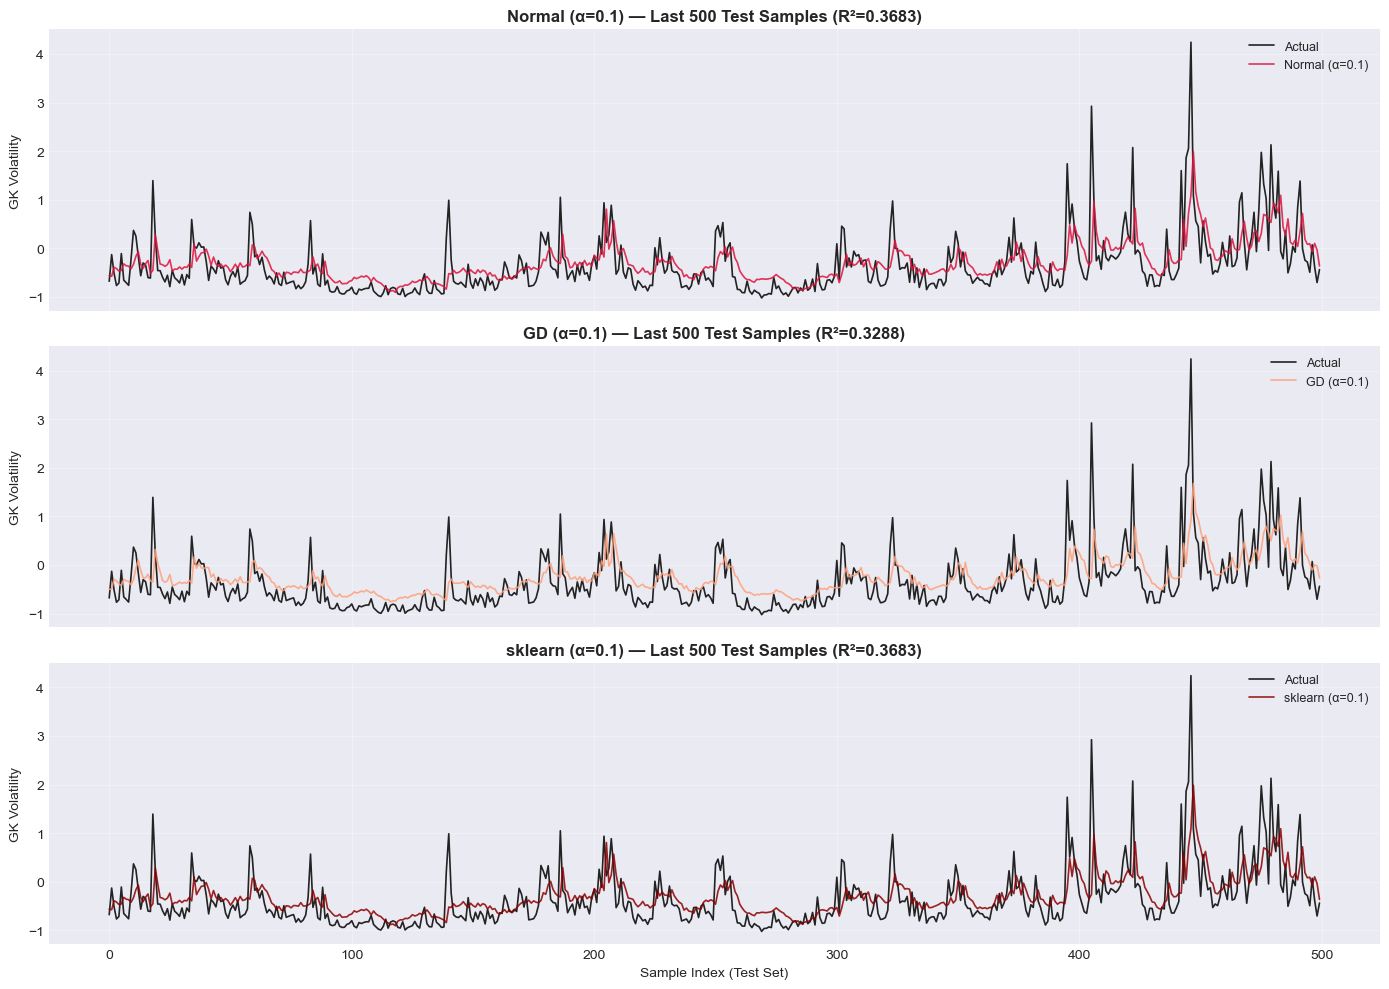

In [14]:
n_plot = 500
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (title, y_pred, color) in zip(axes, pred_list):
    ax.plot(range(n_plot), y_test[-n_plot:], color='black', lw=1.2, label='Actual', alpha=0.85)
    ax.plot(range(n_plot), y_pred[-n_plot:], color=color,   lw=1.2, label=title,   alpha=0.85)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title} — Last {n_plot} Test Samples (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('GK Volatility'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample Index (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ridge_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 16. Coefficient Analysis

Ridge shrinks all coefficients  compare against Linear to see the regularisation effect.

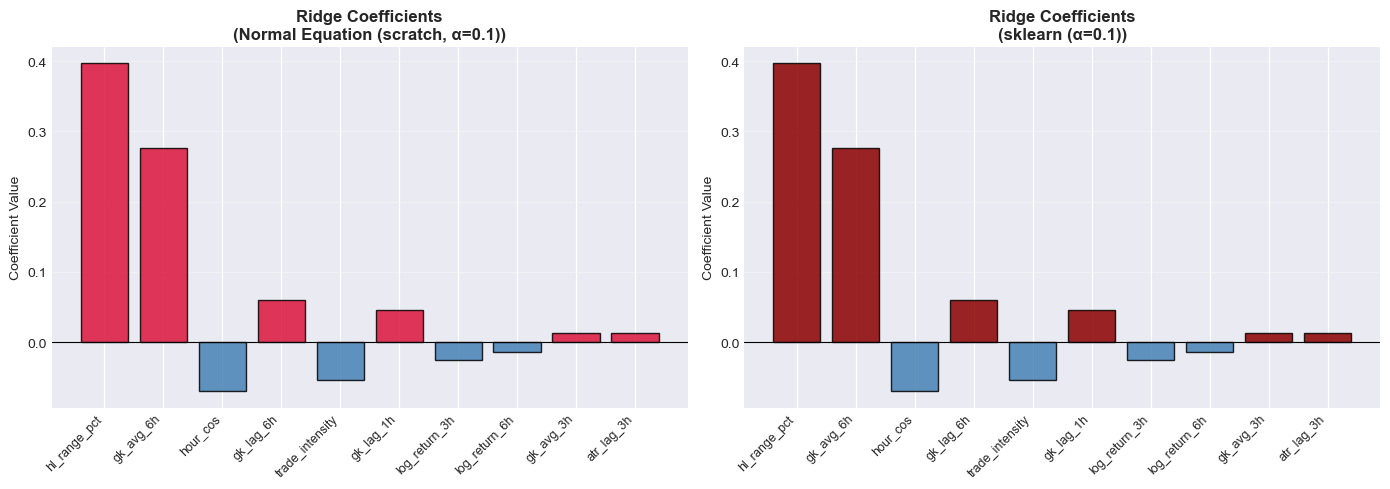

In [15]:
coefs_normal = ridge_normal.get_coefficients(feature_cols)
coefs_sk     = pd.Series(ridge_sk.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coefs, title, color in [
    (axes[0], coefs_normal, f'Normal Equation (scratch, α={best_alpha})', 'crimson'),
    (axes[1], coefs_sk,     f'sklearn (α={best_alpha})',                  'darkred')
]:
    bar_colors = [color if v > 0 else 'steelblue' for v in coefs.values]
    ax.bar(coefs.index, coefs.values, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticklabels(coefs.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Coefficient Value')
    ax.set_title(f'Ridge Coefficients\n({title})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ridge_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 17. Save & Load Models

In [16]:
with open(os.path.join(MODELS_DIR, 'ridge_normal_scratch.pkl'), 'wb') as f: pickle.dump(ridge_normal, f)
with open(os.path.join(MODELS_DIR, 'ridge_gd_scratch.pkl'),    'wb') as f: pickle.dump(ridge_gd,     f)
with open(os.path.join(MODELS_DIR, 'ridge_sklearn.pkl'),        'wb') as f: pickle.dump(ridge_sk,     f)
with open(os.path.join(MODELS_DIR, 'ridge_scaler.pkl'),         'wb') as f: pickle.dump(scaler,      f)
print('Models saved to:', MODELS_DIR)

with open(os.path.join(MODELS_DIR, 'ridge_normal_scratch.pkl'), 'rb') as f: m = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'ridge_scaler.pkl'),         'rb') as f: s = pickle.load(f)
X_new = s.transform(test[feature_cols].values)
print(f'Load verification — R²: {r2_score(y_test, m.predict(X_new)):.6f}  OK')


Models saved to: d:\ML\crypto project\cryptoflow\models
Load verification — R²: 0.368318  OK


---
## 18. Final Summary

In [17]:
print('='*65)
print('  RIDGE REGRESSION — FINAL SUMMARY')
print('='*65)
print(f'Best alpha (λ) : {best_alpha}')
print('\n--- Regression Metrics (Test Set) ---')
for name, m in all_metrics.items():
    print(f'  {name:35s}  MSE={m["mse"]:.6e}  RMSE={m["rmse"]:.6e}  R²={m["r2"]:.4f}')
print('='*65)
print(f'\nAll plots saved to : {PLOTS_DIR}')
print(f'Results saved to   : {RESULTS_CSV}')


  RIDGE REGRESSION — FINAL SUMMARY
Best alpha (λ) : 0.1

--- Regression Metrics (Test Set) ---
  Ridge Normal (scratch, α=0.1)        MSE=1.847280e-01  RMSE=4.298000e-01  R²=0.3683
  Ridge GD (scratch, α=0.1)            MSE=1.962753e-01  RMSE=4.430296e-01  R²=0.3288
  Ridge sklearn (α=0.1)                MSE=1.847280e-01  RMSE=4.298000e-01  R²=0.3683

All plots saved to : d:\ML\crypto project\cryptoflow\plots
Results saved to   : d:\ML\crypto project\cryptoflow\results\regression_results.csv
